Імпортую потрібні для виконання лабораторної роботи бібліотеки

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## **Завдання 2.1**

В онлайн-репозиторії вихідного коду відсутній (насправді, його було перенесено для цієї вправи) код, який створює Рисунок 2.2. Напишіть власний вихідний код, щоб згенерувати та відобразити Рисунок 2.2


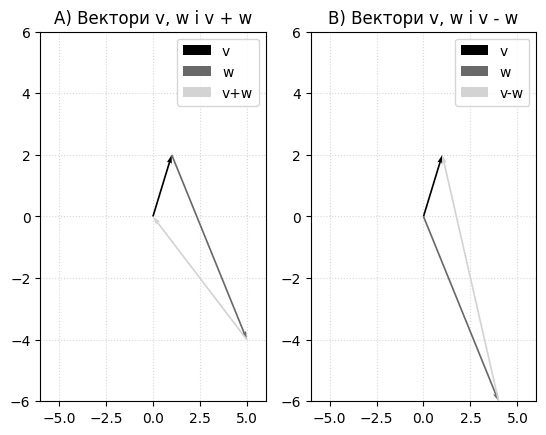

In [3]:
# Малюнок A: 
plt.subplot(1, 2, 1)
plt.title("A) Вектори v, w і v + w")
plt.grid(True, linestyle=':', alpha=0.5, zorder=0)
plt.quiver(0, 0, 1, 2, angles='xy', scale_units='xy', scale=1, color='black', label='v', zorder=2)
plt.quiver(1,2,4,-6, angles='xy', scale_units='xy', scale=1, color='dimgray', label='w', zorder=2)
plt.quiver(5, -4, -5, 4, angles='xy', scale_units='xy', scale=1, color='lightgray', label='v+w', zorder=2)
ticks = np.arange(-6, 7, 2)
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.legend()

# Малюнок B: 
plt.subplot(1, 2, 2)
plt.title("B) Вектори v, w і v - w")
plt.grid(True, linestyle=':', alpha=0.5, zorder=0)
plt.quiver(0, 0, 1, 2, angles='xy', scale_units='xy', scale=1, color='black', label='v', zorder=2)
plt.quiver(0, 0, 4, -6 , angles='xy', scale_units='xy', scale=1, color='dimgray', label='w', zorder=2)
plt.quiver(4, -6, -3, 8, angles='xy', scale_units='xy', scale=1, color='lightgray', label='v-w', zorder=2)
ticks = np.arange(-6, 7, 2)
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.legend()

plt.show()


## **Завдання 2.2**
Напишіть алгоритм (функцію), який обчислює норму вектора, реалізуючи рівняння, подібне до 2.7, у вашому коді. Підтвердьте, використовуючи кілька тестових векторів з різною розмірністю та орієнтацією, що ви отримуєте той самий результат, що й вбудована функція np.linalg.norm().

In [7]:
random_dim = np.random.randint(2, 6) 
random_vector = np.random.randint(low=-10, high=10, size=random_dim)
form_choice = np.random.randint(0, 2)
if form_choice == 1:
    random_vector = random_vector.reshape(random_dim, 1)
print(f"\n\033[1mВипадковий вектор:\n{random_vector}\n \033[0m")

v_norm1 = np.linalg.norm(random_vector)
print(f"Норма вектора обчислена за допомогою np.linalg.norm() {round(v_norm1,3)}")
 
def calculate_vector_norm(v):
    v_flat = v.flatten() 
    sum_of_squares = 0
    for element in v_flat:
        sum_of_squares += element**2
    norm = np.sqrt(sum_of_squares)
    return norm

v_norm2=calculate_vector_norm(random_vector)
print(f"Норма вектора обчислена за допомогою власноруч створеної функції {round(v_norm2,3)}\n")

if v_norm1 == v_norm2:
    print('Норми вектора пораховані двома методами є рівними.')
else:
    print('Норми вектора пораховані двома методами є різними.')



Випадковий вектор:
[[-1]
 [-8]
 [-4]]
 
Норма вектора обчислена за допомогою np.linalg.norm() 9.0
Норма вектора обчислена за допомогою власноруч створеної функції 9.0

Норми вектора пораховані двома методами є рівними.


## **Завдання 2.3**
Створіть функцію Python, яка приймає на вхід вектор і повертає одиничний вектор (вектор довжиною 1) у тому ж напрямку. Що відбувається, коли на вхід подається нульовий вектор (вектор з усіх нулів)?

In [12]:
def get_user_vector(): 
    while True:
        try:
            vector_str = input("Введіть елементи вектора через пробіл: ")
            user_vector = np.array([float(x) for x in vector_str.split()])
            if user_vector.size == 0:
                print("Ви не ввели жодного елемента. \nСпробуйте ще раз.")
                continue

            orientation_choice = input( "Введіть орієнтацію вектора рядок/стовпець: ").lower()
            if orientation_choice in ["стовпець", "column"]:
                user_vector = user_vector.reshape(-1, 1) 
            elif orientation_choice in ["рядок", "row"]:
                pass
            else:
                print("Некоректний вибір орієнтації. \nСпробуйте ще раз.")
                continue 
            return user_vector
        except ValueError:
            print("Помилка. Некоректні дані. \nБудь ласка, введіть лише числа, розділені пробілами.")

In [13]:
random_vector = get_user_vector()
print(f"\n\033[1mВектор:\n{random_vector}\n \033[0m")
# Функція для пошуку одиничного вектора 
def vector_normalization(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        print(f"Неможливо знайти одиничний вектор для вектора {v}.")
        return None 
    normal_vector = v / norm
    print(f"\nНормалізованиий вектор:\n{normal_vector}")
    return normal_vector
v = vector_normalization(random_vector)


Вектор:
[5. 7.]
 

Нормалізованиий вектор:
[0.58123819 0.81373347]


## **Завдання 2.4**
Ви знаєте, як створювати одиничні вектори; що, якщо ви хочете створити вектор будь-якого довільного модуля (довжини)?
Напишіть функцію Python, яка на вхід прийматиме вектор і бажаний модуль вектора, і повертатиме вектор у тому ж напрямку, але з модулем, що відповідає другому вхідному аргументу.

In [16]:
vector = get_user_vector()
print(f"\nВектор \033[1ma\033[0m:\n{vector}")

def resize_vector(v, new_length): 
    norm = np.linalg.norm(v)
    if norm == 0:
        print(f"Неможливо знайти одиничний вектор для вектора {v}.")
        return None
    res_vector = (v / norm)* new_length
    print(f"Вектор співнапрямлений з вектором \033[1ma\033[0m та моделем {new_length}: \n{res_vector.round(2)}")
    return res_vector
while True:
    try:
        new_len = float(input("Введіть бажану довжину вектора: "))
        if new_len < 0:
            print("Довжина не може бути від’ємною!")
        else:
            break
    except ValueError:
        print("Помилка! Довжина має бути цілим числом.")
m=resize_vector(vector,new_len)


Вектор a:
[3. 4.]
Вектор співнапрямлений з вектором a та моделем 10.0: 
[6. 8.]


## **Завдання 2.5**
Напишіть цикл for для транспонування вектора-рядка у вектор-стовпець (або навпаки) без використання вбудованих функцій або методів, таких як np.transpose(), .T або reshape().

In [35]:
v_row = np.array([1, 2, 3])
v_col = np.array([[10], [20], [30]])

def transpose(v):
    if len(v.shape) == 1:
        transposed_v = np.zeros(shape=(v.size, 1))
        for i in range(v.size):
            transposed_v[i, 0] = v[i]
        return transposed_v
    
    else: 
        transposed_v = np.zeros(shape=(v.size))
        for i in range(v.size):
            transposed_v[i] = v[i, 0] 
        return transposed_v
    
print('Вектор-рядок',v_row)
print('Транспонований вектор-стовпець', transpose(v_row))
print('\nВектор-стовпець\n',v_col)
print('Транспонований вектор-рядок',transpose(v_col))

Вектор-рядок [1 2 3]
Транспонований вектор-стовпець [[1.]
 [2.]
 [3.]]

Вектор-стовпець
 [[10]
 [20]
 [30]]
Транспонований вектор-рядок [10. 20. 30.]


## **Завдання 2.6**
Квадратна норма вектора може обчислюватися як скалярний (точковий) добуток цього вектора на себе.
Поверніться до рівності з прикладу 2.8, щоб переконатися в даній еквівалентності.
Підтвердьте цю еквівалентність за допомогою Python (тобто порівняйте квадрат норми, обчисленої одним способом, із результатом скалярного добутку).
$$||x|| = \sqrt{\sum_{i=1}^n x_i^2} = \sqrt{x_1x_1 + \ldots +x_nx_n} = \sqrt{(x\, |\, x)} \implies $$ $$\implies ||x||^2 = (x\, |\, x)$$

In [41]:
vector = get_user_vector()
norm_squared = np.linalg.norm(vector)**2
dot_product = np.dot(vector.T, vector)
print("Вектор:", vector)
print("v^2 =", norm_squared)
print("v·v =", dot_product)

# перевірка рівності
print("Чи рівні значення:", np.isclose(norm_squared, dot_product))

Вектор: [[4.]
 [5.]]
v^2 = 41.0
v·v = [[41.]]
Чи рівні значення: [[ True]]


## **Завдання 2.7**
Комутативна властивість означає a⋅b=b⋅a, що для точкового добутку векторів виражається як aTb=bTa.
Напишіть вихідний код, щоб продемонструвати, що точковий добуток є комутативним. Застосуйте рівність з прикладу 2.9, щоб зрозуміти, чому ця властивість виконується.

In [44]:
a = get_user_vector()
b = get_user_vector()

#перевірка ab=ba
if len(a) != len(b):
    print("Вектори мають різну довжину! Неможливо знайти скалярний добуток.")
else:
    a_dot_b = np.dot(a, b)
    b_dot_a = np.dot(b, a)
    at_dot_b=np.dot(a.T,b)
    bt_dot_a=np.dot(b.T,a)

print(f"Вектор a: {a}")
print(f"Вектор b: {b}")

print(f"Перевірка комутативності a·b = b·a: {np.isclose(a_dot_b, b_dot_a)}")
print(f"Перевірка комутативності aT·b = bT·a: {np.isclose(a_dot_b, b_dot_a)}")

Вектор a: [6. 7.]
Вектор b: [7. 9.]
Перевірка комутативності a·b = b·a: True
Перевірка комутативності aT·b = bT·a: True


## **Завдання 2.8**
Напишіть вихідний код створення Рисунка 2.6. (Зверніть увагу: якщо присутні ключові елементи, ваш розв'язок не обов'язково має виглядати точно так, як на рисунку.)

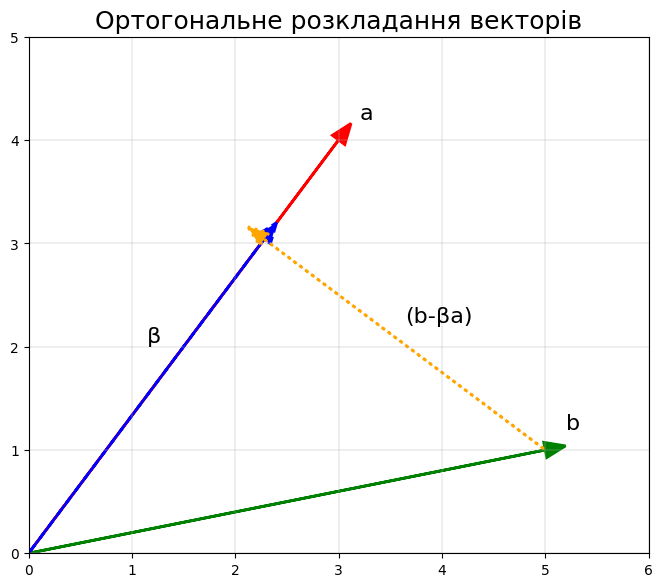

In [75]:
a = np.array([3, 4])
b = np.array([5, 1])
beta = np.dot(a, b) / np.dot(a, a)
projection_of_b_on_a = beta * a
perpendicular_vector = b - projection_of_b_on_a

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', adjustable='box')

ax.set_xlim([0, 6])
ax.set_ylim([0, 5])

ax.arrow(0, 0, a[0], a[1], head_width=0.15, head_length=0.2, fc='red', ec='red', lw=2)
ax.arrow(0, 0, b[0], b[1], head_width=0.15, head_length=0.2, fc='green', ec='green', lw=2)

ax.arrow(0, 0, projection_of_b_on_a[0], projection_of_b_on_a[1],
         linestyle='--', color='blue', lw=2, head_width=0.15, head_length=0.2)
ax.arrow(b[0], b[1], -perpendicular_vector[0], -perpendicular_vector[1],
         linestyle=':', color='orange', lw=2, head_width=0.15, head_length=0.2)


ax.text(a[0] + 0.2, a[1] + 0.2, 'a', fontsize=16)
ax.text(b[0] + 0.2, b[1] + 0.2, 'b', fontsize=16)
ax.text(projection_of_b_on_a[0] / 2, projection_of_b_on_a[1] - 1, 'β', fontsize=16)
ax.text(b[0] - perpendicular_vector[0] / 2, b[1] - perpendicular_vector[1] - 0.8, '(b-βa)', fontsize=16)
plt.grid(True, linewidth=0.3)
plt.title('Ортогональне розкладання векторів', fontsize=18)
plt.show()

## **Завдання 2.9**
Реалізуйте ортогональне розкладання векторів. Почніть з двох векторів випадкових чисел t і r і відтворіть рис. 2.8 (зверніть увагу, що ваш графік буде виглядати дещо інакше через випадкові числа). Потім підтвердіть, що сума двох компонент дорівнює $\mathbf{t}$ і що $\mathbf{t}_{\perp \mathbf{r}}$ і $\mathbf{t}_{\parallel \mathbf{r}}$ ортогональні.

Вектор t: [0.47878271 1.20187942]
Вектор r: [0.43402646 0.65360602]
t_parallel [0.7003877  1.05472284]
t_perpendicular [-0.22160499  0.14715659]
t_parallel + t_perpendicular = [0.47878271 1.20187942]
Вектори t_parallel і t_perpendicular ортогональні: True


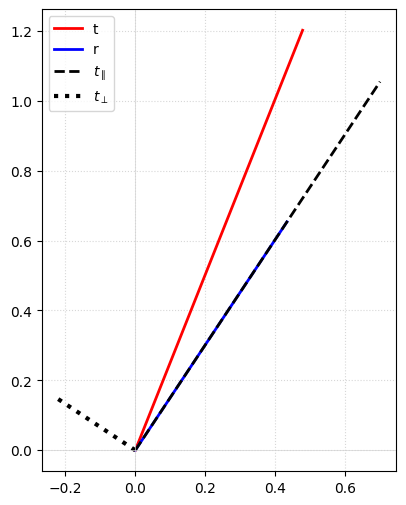

In [78]:
t = np.random.randn(2)
print('Вектор t:',t)
r = np.random.randn(2)
print('Вектор r:',r)

t_parallel = (np.dot(t.T, r) / np.dot(r.T, r)) * r
print('t_parallel',t_parallel)
t_perpendicular = t - t_parallel
print('t_perpendicular',t_perpendicular)
print("t_parallel + t_perpendicular =", t_parallel + t_perpendicular)
print("Вектори t_parallel і t_perpendicular ортогональні:", np.isclose(np.dot(t_parallel, t_perpendicular), 0))  

plt.figure(figsize=(6,6))
plt.plot([0, t[0]], [0, t[1]], color="red", linewidth=2, label="t")
plt.plot([0, r[0]], [0, r[1]], color="blue", linewidth=2, label="r")
plt.plot([0, t_parallel[0]], [0, t_parallel[1]], "k--", linewidth=2, label=r"$t_{\parallel}$")
plt.plot([0, t_perpendicular[0]], [0, t_perpendicular[1]], "k:", linewidth=3, label=r"$t_{\perp}$")
plt.grid(True, linestyle=':', alpha=0.5, zorder=0)
plt.gca().set_aspect("equal", adjustable="box")
plt.axhline(0, color="lightgray", linewidth=0.5)
plt.axvline(0, color="lightgray", linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

## **Завдання 2.10**
Важливою навичкою програмування є пошук помилок. Припустімо, у вашому вихідному коді є дефект, через який знаменник у проекційному скалярі з прикладу 2.13 дорівнює $\mathbf{t}^\top \mathbf{t}$ замість $\mathbf{r}^\top \mathbf{r}$ (виходячи з особистого досвіду написання цього коду, легко припуститися помилки!). Зробіть цю помилку, щоб перевірити, чи справді вона веде в бік від точного вихідного коду. Що можна зробити, щоб перевірити, чи результат правильний чи неправильний? (У програмуванні підтвердження вихідного коду відомими результатами називається перевіркою на справжність).

In [89]:
t = np.array([3,7]) 
r = np.array([8,9]) 

tT_dot_r = np.dot(t.T, r)  
rT_dot_r = np.dot (r.T, r) 
tT_dot_t = np.dot(t.T, t) 

print(f"Вектор t: {t}")
print(f"Вектор r: {r}")

t_parallel_error = r * (tT_dot_r / tT_dot_t)
t_perp_error = t - t_parallel_error

print(f"Неправильна ортогональна складова: \n{t_parallel_error}")
print(f"Неправильна проекція:\n{t_perp_error}")
verification_scalar=np.dot(t_perp_error.T, r)
print(f"Перевірка чи dot(t_perp_error.T, r_col) = 0: \ndot(t_perp_error.T, r_col) = {verification_scalar} - не дорівнює нулю")
if np.isclose(verification_scalar, 0):
    print('Формула правильна, але це випадковість.')
else:
    print("У формулі помилка.")

Вектор t: [3 7]
Вектор r: [8 9]
Неправильна ортогональна складова: 
[12.  13.5]
Неправильна проекція:
[-9.  -6.5]
Перевірка чи dot(t_perp_error.T, r_col) = 0: 
dot(t_perp_error.T, r_col) = -130.5 - не дорівнює нулю
У формулі помилка.
